In [ ]:
import sys
sys.path.append("./")   # vì deepfm.py nằm cùng thư mục notebook

import torch
import pandas as pd
from deepfm import DeepFM

In [19]:
# Đọc dataset
df = pd.read_csv("../Dataset/QK-video_subset_5M.csv")  # đổi đường dẫn cho đúng


categorical_cols = ['user_id', 'item_id', 'video_category', 'gender', 'age']
numeric_cols = ['watching_times']
target_col = 'click'

# Đếm unique cho từng categorical feature
cat_dims = [df[col].nunique() for col in categorical_cols]
num_dim = len(numeric_cols)

print("✅ Categorical dims:", cat_dims)
print("✅ Number of numeric features:", num_dim)


✅ Categorical dims: [295751, 450906, 3, 3, 8]
✅ Number of numeric features: 1


In [20]:
state_dict = torch.load("../Model/Deep FM/video/deepfm_model.pth", map_location='cuda' if torch.cuda.is_available() else 'cpu')
for k in state_dict.keys():
    if "embeddings" in k:
        print(k, state_dict[k].shape)

embeddings.0.weight torch.Size([295751, 8])
embeddings.1.weight torch.Size([450906, 8])
embeddings.2.weight torch.Size([3, 8])
embeddings.3.weight torch.Size([3, 8])
embeddings.4.weight torch.Size([8, 8])


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7776\2124309823.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("../Model/Deep FM/video/deepfm_model.

In [22]:
# Load checkpoint
state_dict = torch.load("../Model/Deep FM/video/deepfm_model.pth", map_location='cuda' if torch.cuda.is_available() else 'cpu')

# Khởi tạo model với đúng cấu hình lúc train
model = DeepFM(cat_dims, num_dim=num_dim, embed_dim=8, hidden_dims=[128, 64])
model.load_state_dict(state_dict)
model.eval()

print(model)


DeepFM(
  (embeddings): ModuleList(
    (0): Embedding(295751, 8)
    (1): Embedding(450906, 8)
    (2-3): 2 x Embedding(3, 8)
    (4): Embedding(8, 8)
  )
  (linear): Linear(in_features=41, out_features=1, bias=True)
  (dnn): Sequential(
    (0): Linear(in_features=41, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7776\6670111.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("../Model/Deep FM/video/deepfm_model.pth

In [23]:
for i, emb in enumerate(model.embeddings):
    print(f"Embedding {i}: {categorical_cols[i]} -> {emb}")


Embedding 0: user_id -> Embedding(295751, 8)
Embedding 1: item_id -> Embedding(450906, 8)
Embedding 2: video_category -> Embedding(3, 8)
Embedding 3: gender -> Embedding(3, 8)
Embedding 4: age -> Embedding(8, 8)


In [24]:
# Ví dụ visualize item_id embedding
feature_index = 1  # 0=user_id, 1=item_id, 2=video_category, 3=gender, 4=age

embedding_weights = model.embeddings[feature_index].weight.detach().cpu().numpy()
print("Embedding shape:", embedding_weights.shape)

Embedding shape: (450906, 8)


c:\Users\ADMIN\.conda\envs\tf215\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


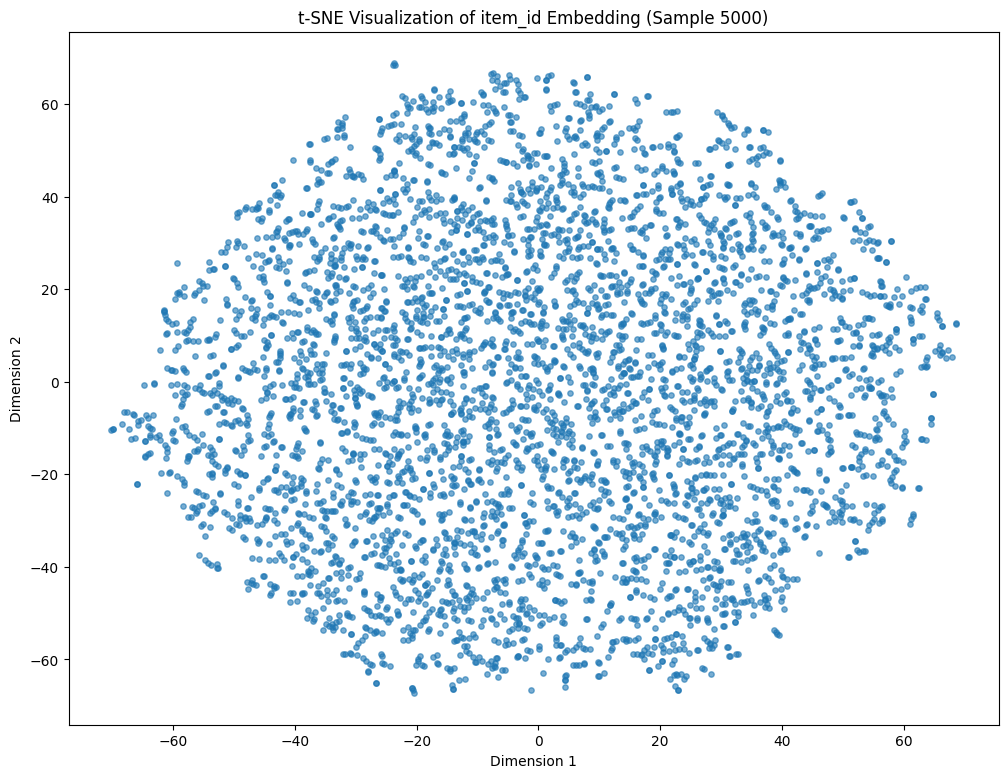

In [26]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# 🎯 Lấy mẫu 5,000 điểm ngẫu nhiên từ toàn bộ embedding
sample_size = 5000
sample_idx = np.random.choice(embedding_weights.shape[0], sample_size, replace=False)
embedding_sample = embedding_weights[sample_idx]

# 🔽 Chạy t-SNE trên mẫu
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
embedding_2d = tsne.fit_transform(embedding_sample)

# 🎨 Vẽ biểu đồ
plt.figure(figsize=(12, 9))
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], alpha=0.6, s=15)
plt.title(f"t-SNE Visualization of {categorical_cols[feature_index]} Embedding (Sample {sample_size})")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

c:\Users\ADMIN\.conda\envs\tf215\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


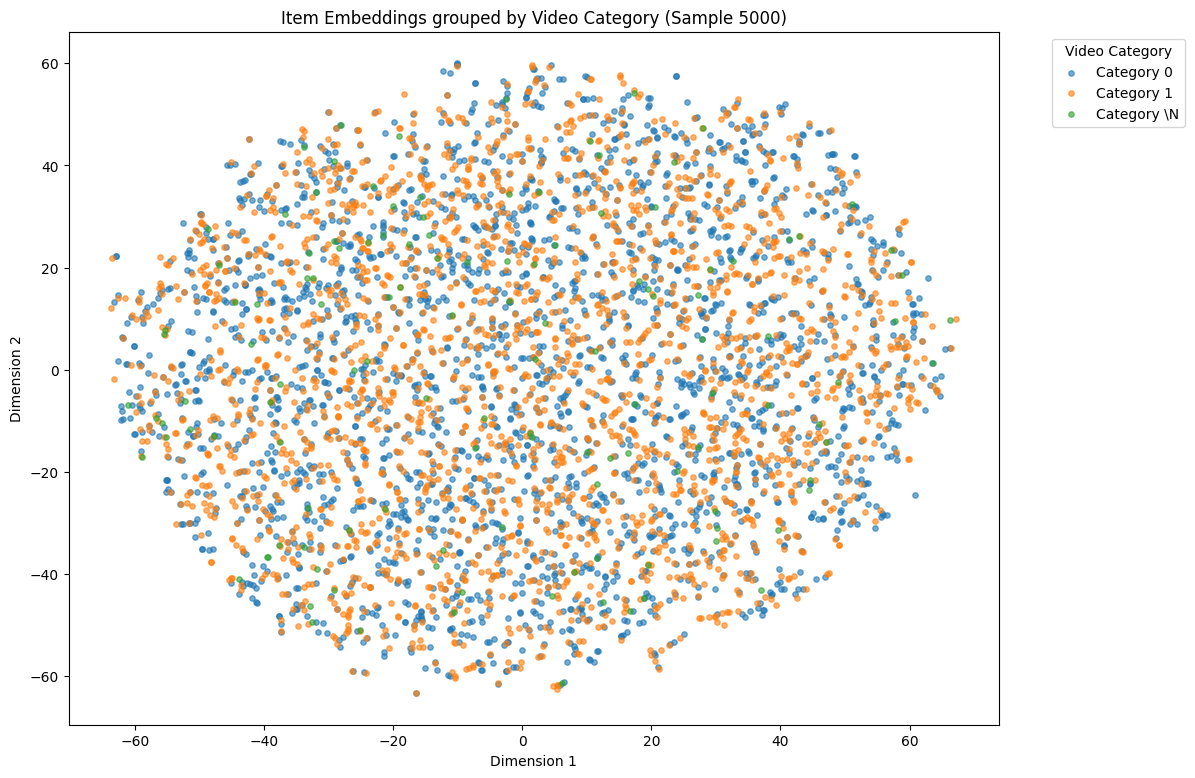

In [28]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# 🎯 Lấy mẫu 5,000 item_id ngẫu nhiên
sample_size = 5000
sample_idx = np.random.choice(embedding_weights.shape[0], sample_size, replace=False)

embedding_sample = embedding_weights[sample_idx]

# 🏷 Lấy nhãn (ví dụ video_category) cho cùng index
# 👉 Phải tạo map item_id → video_category trước
item_cat_map = df[['item_id', 'video_category']].drop_duplicates().sort_values('item_id')
categories = np.array(item_cat_map['video_category'].tolist())   # list tất cả category theo item_id
categories_sample = categories[sample_idx]  # chỉ lấy label cho sample

# 🔽 Chạy t-SNE trên sample
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
embedding_2d = tsne.fit_transform(embedding_sample)

# 🎨 Vẽ scatter plot với màu theo category
plt.figure(figsize=(12, 9))
unique_cats = sorted(set(categories_sample))

for cat in unique_cats:
    idx = categories_sample == cat
    plt.scatter(embedding_2d[idx, 0],
                embedding_2d[idx, 1],
                label=f"Category {cat}",
                s=15, alpha=0.6)

plt.legend(title="Video Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title(f"Item Embeddings grouped by Video Category (Sample {sample_size})")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()
